# 04 — Baseline Models

Train rule-based, logistic regression, and XGBoost baselines. Quantify event-only vs event+360 performance.

In [9]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import yaml
from src.data.splits import create_match_level_splits
from src.features.event_features import build_event_features
from src.features.geometry_features import build_geometry_features
from src.models.baselines import RuleBasedLineBreak, RuleBasedDangerousProgression
from src.models.tabular import TabularClassifier, MultitaskTabular
from src.evaluation.metrics import classification_metrics, summarise_all_tasks

with open("../configs/model_baseline.yaml") as f:
    model_cfg = yaml.safe_load(f)


## 1. Load data and split

In [2]:

pass_instances = pd.read_parquet("../data/processed/pass_instances.parquet")
train_df = pd.read_parquet("../data/processed/train.parquet")
val_df = pd.read_parquet("../data/processed/val.parquet")
test_df = pd.read_parquet("../data/processed/test.parquet")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")


Train: 36,037 | Val: 7,307 | Test: 7,344


## 2. Build features

In [3]:

X_train = build_event_features(train_df)
X_val   = build_event_features(val_df)
X_test  = build_event_features(test_df)
print(f"Event features: {X_train.shape[1]} columns")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")


Event features: 27 columns
X_train: (36037, 27), X_val: (7307, 27), X_test: (7344, 27)


## 3. Rule-based baseline

In [4]:

# Filter to passes that have line-break labels (360 data required)
test_360 = test_df[test_df["has_360"]].copy()

model_rb = RuleBasedLineBreak()
preds_rb = model_rb.predict(test_360)
y_true_rb = test_360["strict_line_break"].fillna(0).astype(int)
metrics_rb = classification_metrics(y_true_rb, preds_rb.astype(float))
print("Rule-based line-break (test, 360 only):")
for k, v in metrics_rb.items():
    print(f"  {k}: {v:.4f}")


Rule-based line-break (test, 360 only):
  roc_auc: 0.6373
  pr_auc: 0.4922
  log_loss: 10.1493
  brier_score: 0.2816
  f1: 0.4687
  precision: 0.7412
  recall: 0.3427
  accuracy: 0.7184


## 4. Logistic regression (event-only)

In [8]:

from sklearn.preprocessing import StandardScaler

# Use all passes for dangerous_progression_k (no 360 required)
y_train_dp = train_df["dangerous_progression_k"].fillna(0).astype(int)
y_val_dp = val_df["dangerous_progression_k"].fillna(0).astype(int)

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)

lr_cfg = {**model_cfg["logistic_regression"], "max_iter": 5000}
clf_lr = TabularClassifier(model_type="logistic", task="dangerous_progression_k",
                           config=lr_cfg)
clf_lr.fit(X_train_scaled, y_train_dp)
probs_lr = clf_lr.predict_proba(X_val_scaled)[:, 1]
metrics_lr = classification_metrics(y_val_dp, probs_lr)
print("Logistic regression — dangerous_progression_k (val):")
for k, v in metrics_lr.items():
    print(f"  {k}: {v:.4f}")


Logistic regression — dangerous_progression_k (val):
  roc_auc: 0.7681
  pr_auc: 0.7653
  log_loss: 0.5650
  brier_score: 0.1879
  f1: 0.6907
  precision: 0.6896
  recall: 0.6918
  accuracy: 0.7361


## 5. XGBoost (event-only)

XGBoost — dangerous_progression_k (val):
  roc_auc: 0.8603
  pr_auc: 0.8618
  log_loss: 0.4368
  brier_score: 0.1391
  f1: 0.7440
  precision: 0.8430
  recall: 0.6658
  accuracy: 0.8048


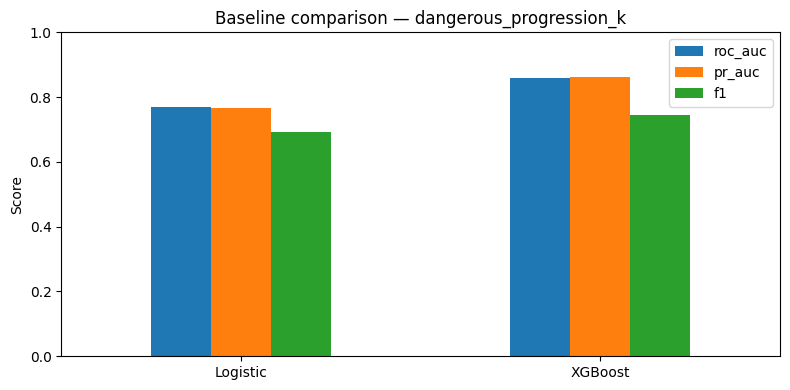

In [6]:

clf_xgb = TabularClassifier(model_type="xgboost", task="dangerous_progression_k",
                            config=model_cfg["xgboost"])
clf_xgb.fit(X_train, y_train_dp, X_val=X_val, y_val=y_val_dp)
probs_xgb = clf_xgb.predict_proba(X_val)[:, 1]
metrics_xgb = classification_metrics(y_val_dp, probs_xgb)
print("XGBoost — dangerous_progression_k (val):")
for k, v in metrics_xgb.items():
    print(f"  {k}: {v:.4f}")

# Compare all baselines
import matplotlib.pyplot as plt
comparison = pd.DataFrame({"Logistic": metrics_lr, "XGBoost": metrics_xgb})
comparison.T[["roc_auc", "pr_auc", "f1"]].plot(kind="bar", figsize=(8, 4), rot=0)
plt.title("Baseline comparison — dangerous_progression_k")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 6. SHAP feature importance

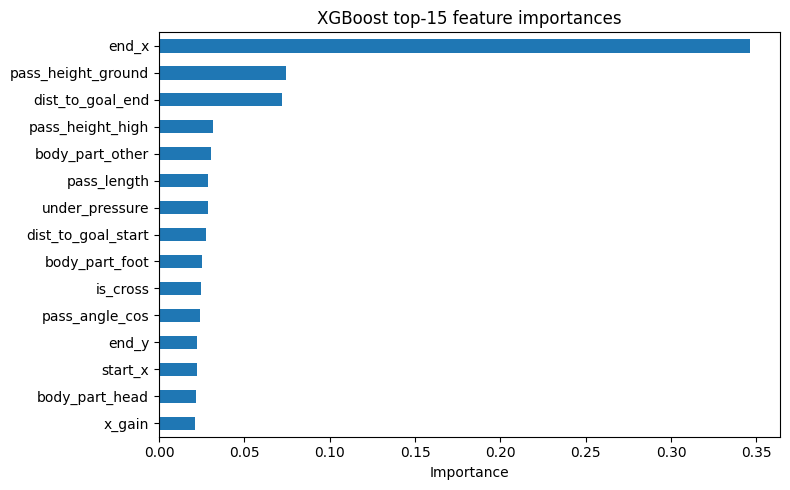

In [7]:

import matplotlib.pyplot as plt
importance = clf_xgb.get_feature_importance().head(15)
fig, ax = plt.subplots(figsize=(8, 5))
importance.sort_values().plot(kind="barh", ax=ax)
ax.set_title("XGBoost top-15 feature importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()
